# EDA: Venta de propiedades

Análisis exploratorio del segmento **venta** a partir de los datos normalizados. El objetivo del modelo es `precio_clp_normalizado` (precio total en CLP).

## Setup

Carga los datos normalizados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats

from src.eda.leer import cargar_properties

sns.set_theme(style="whitegrid", palette="muted")
PALETA = sns.color_palette()

df = cargar_properties(tipo_operacion="venta")
print(f"Total de publicaciones: {len(df)} ventas")

Total de publicaciones: 3330 ventas


## Vista general

Dimensiones, tipos y primeras filas del segmento.

In [2]:
df.shape

(3330, 21)

In [3]:
df.dtypes

id                                int64
fuente                              str
url_origen                          str
tipo_operacion                      str
tipo_propiedad                      str
precio_valor                    float64
precio_moneda                       str
precio_clp_normalizado          float64
m2_util                         float64
m2_total                        float64
gastos_comunes                  float64
dormitorios                     float64
banos                           float64
estacionamientos                float64
bodega                          boolean
comuna                              str
region                              str
antiguedad_anios                float64
descripcion                         str
fecha_publicacion         datetime64[s]
fecha_scraping            datetime64[s]
dtype: object

In [4]:
df.head()

,id,fuente,url_origen,tipo_operacion,tipo_propiedad,precio_valor,precio_moneda,precio_clp_normalizado,m2_util,m2_total,...,dormitorios,banos,estacionamientos,bodega,comuna,region,antiguedad_anios,descripcion,fecha_publicacion,fecha_scraping
0,459,portal_inmobiliario,https://portalinmobiliario.com/MLC-1489652691-...,venta,departamento,4100.0,UF,1.675770e+08,5.0,5.0,...,3.0,2.0,NaN,<NA>,La Florida,NaN,NaN,NaN,NaT,2026-08-30
1,31,portal_inmobiliario,https://portalinmobiliario.com/MLC-1490748447-...,venta,casa,70000.0,UF,2.861072e+09,693.0,2308.0,...,6.0,6.0,5.0,True,Las Condes,RM (Metropolitana),18.0,"Mirene Pérez, nororiente en prestigioso condom...",NaT,2026-08-30
2,105,portal_inmobiliario,https://portalinmobiliario.com/MLC-1558893459-...,venta,casa,18300.0,UF,7.479658e+08,270.0,270.0,...,3.0,3.0,NaN,<NA>,Colina,NaN,NaN,NaN,NaT,2026-08-30
3,192,portal_inmobiliario,https://portalinmobiliario.com/MLC-1580089149-...,venta,casa,315000000.0,CLP,3.150000e+08,197.0,197.0,...,4.0,3.0,NaN,<NA>,Las Cabras,NaN,NaN,NaN,NaT,2026-08-30
4,179,portal_inmobiliario,https://portalinmobiliario.com/MLC-1603223107-...,venta,casa,18900.0,UF,7.724893e+08,211.0,211.0,...,3.0,3.0,NaN,<NA>,Colina,NaN,NaN,NaN,NaT,2026-08-30


## Calidad de datos

Porcentaje de valores nulos por columna y comprobación de duplicados.

In [5]:
nulos = df.isna().mean().mul(100).sort_values(ascending=False)
pd.DataFrame({'%_nulos': nulos})

,%_nulos
gastos_comunes,97.747748
antiguedad_anios,96.996997
bodega,96.366366
descripcion,93.993994
region,93.993994
estacionamientos,90.030030
fecha_publicacion,20.420420
m2_util,10.960961
m2_total,1.171171
banos,0.630631


In [6]:
dup = df.duplicated(subset=['fuente', 'url_origen']).sum()
print('Duplicados por (fuente, url_origen):', dup)

Duplicados por (fuente, url_origen): 0


## Distribución del precio (objetivo)

El objetivo del modelo de valoración es `precio_clp_normalizado` (CLP). Se analiza solo sobre avisos con precio válido (> 0).

In [7]:
precio = df['precio_clp_normalizado'].dropna()
precio = precio[precio > 0]
print('Avisos con precio válido:', len(precio), '/', len(df))
precio.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

Avisos con precio válido: 3330 / 3330


count    3.330000e+03
mean     5.310882e+08
std      4.595830e+08
min      3.042000e+03
1%       6.499999e+07
5%       9.000000e+07
25%      2.150403e+08
50%      4.231280e+08
75%      6.904439e+08
95%      1.346082e+09
99%      2.282174e+09
max      6.311718e+09
Name: precio_clp_normalizado, dtype: float64

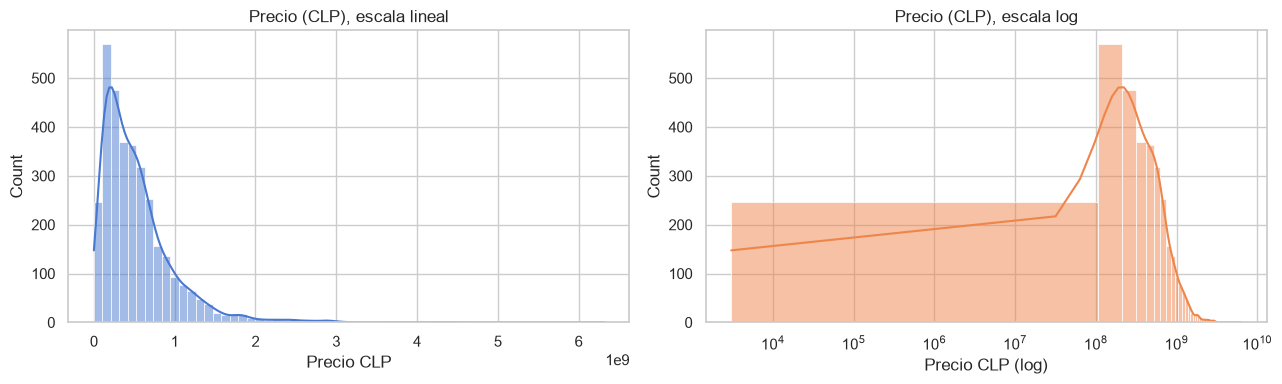

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(precio, bins=60, kde=True, ax=axes[0], color=PALETA[0])
axes[0].set_title('Precio (CLP), escala lineal')
axes[0].set_xlabel('Precio CLP')
sns.histplot(precio, bins=60, kde=True, ax=axes[1], color=PALETA[1])
axes[1].set_xscale('log')
axes[1].set_title('Precio (CLP), escala log')
axes[1].set_xlabel('Precio CLP (log)')
plt.tight_layout(); plt.show()

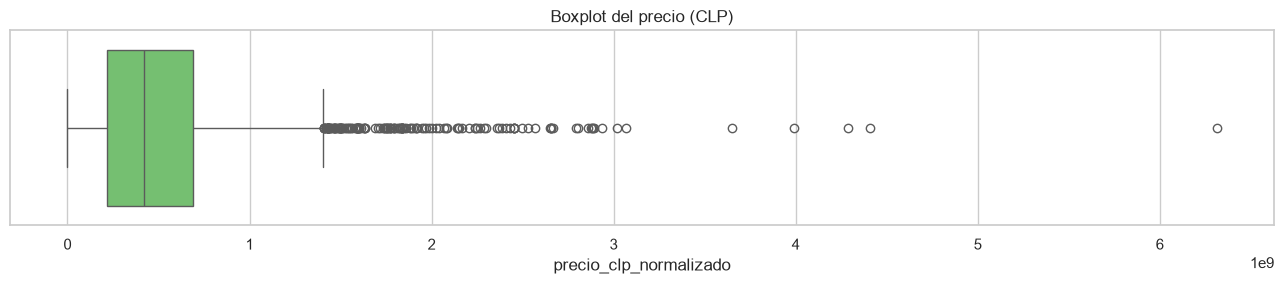

In [9]:
fig, ax = plt.subplots(figsize=(13, 3))
sns.boxplot(x=precio, ax=ax, color=PALETA[2])
ax.set_title('Boxplot del precio (CLP)')
plt.tight_layout(); plt.show()

## Precio por m²

Rasgo derivado clave para la valoración: precio CLP por m² útil y por m² total.

In [10]:
relevante = df[
    df['precio_clp_normalizado'].gt(0)
    & df['m2_util'].gt(0)
    & df['m2_total'].gt(0)
].copy()
relevante['precio_por_m2_util'] = (
    relevante['precio_clp_normalizado'] / relevante['m2_util']
)
relevante['precio_por_m2_total'] = (
    relevante['precio_clp_normalizado'] / relevante['m2_total']
)
print('Avisos con m2 util y total:', len(relevante))
relevante[['precio_por_m2_util', 'precio_por_m2_total']].describe()

Avisos con m2 util y total: 2962


,precio_por_m2_util,precio_por_m2_total
count,2.962000e+03,2.962000e+03
mean,2.872690e+06,2.244460e+06
std,5.466898e+06,4.255285e+06
min,5.155932e+01,5.155932e+01
25%,1.723010e+06,9.493618e+05
50%,2.683253e+06,1.943838e+06
75%,3.512270e+06,3.089671e+06
max,1.866509e+08,1.618349e+08


## Variables numéricas

Estadísticos y histogramas de las características numéricas.

In [11]:
numericas = ['m2_util', 'm2_total', 'gastos_comunes', 'dormitorios',
             'banos', 'estacionamientos', 'antiguedad_anios']
df[numericas].describe()

,m2_util,m2_total,gastos_comunes,dormitorios,banos,estacionamientos,antiguedad_anios
count,2965.000000,3291.000000,75.000000,3317.000000,3309.000000,332.000000,100.000000
mean,467.396263,832.844263,108833.253333,3.563461,2.947114,2.325301,13.960000
std,1153.853967,1771.977606,166654.041589,1.622732,1.563812,1.747564,12.312365
min,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,95.000000,97.000000,1.000000,3.000000,2.000000,1.000000,4.750000
50%,165.000000,205.000000,50000.000000,3.000000,3.000000,2.000000,11.500000
75%,300.000000,584.000000,157500.000000,4.000000,4.000000,3.000000,20.250000
max,17388.000000,44000.000000,1000000.000000,35.000000,37.000000,10.000000,61.000000


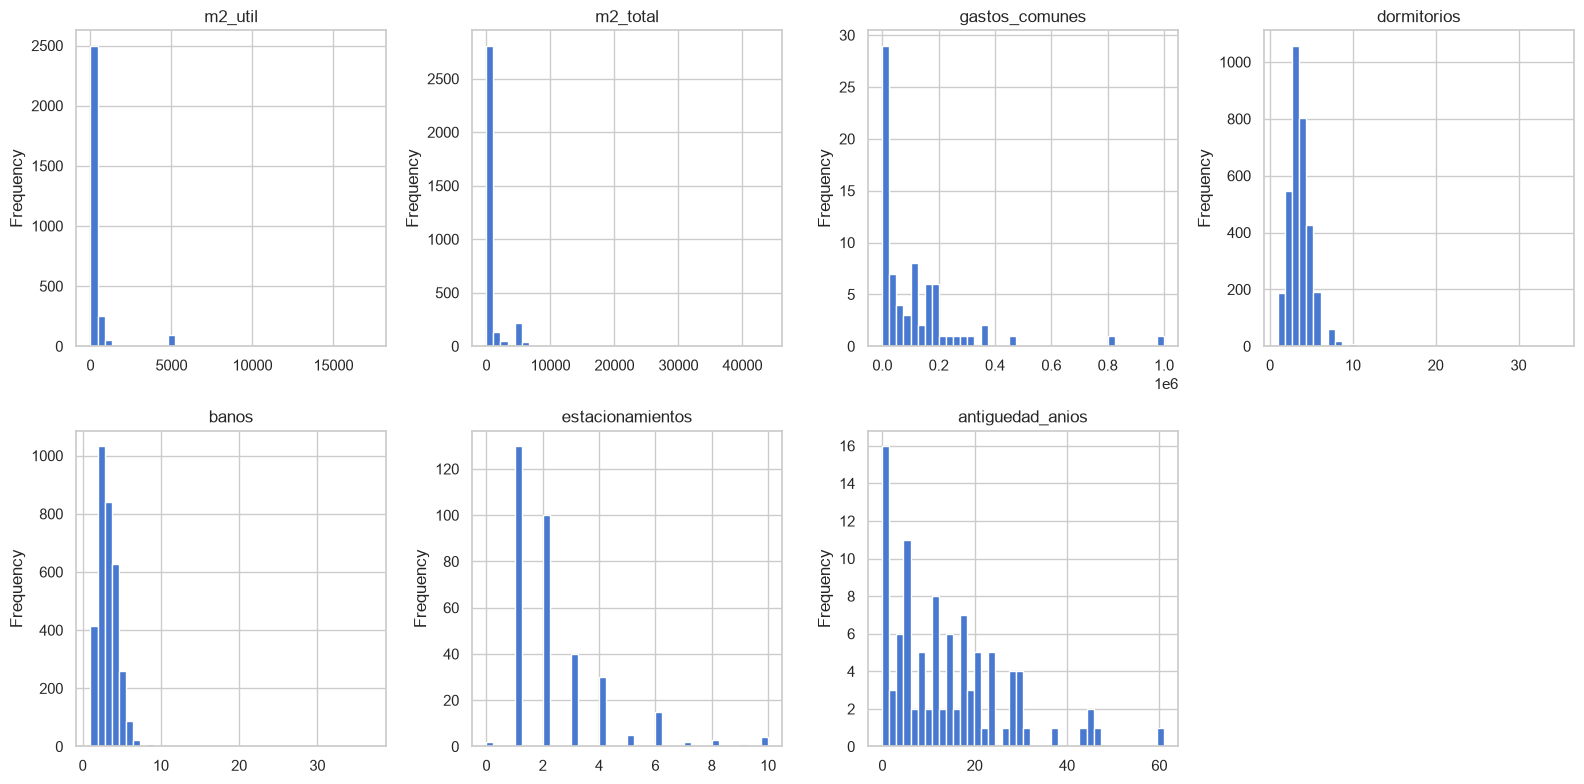

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(numericas):
    valores = df[col].dropna()
    valores.plot.hist(bins=40, ax=axes[i], title=col)
    axes[i].set_xlabel('')
for j in range(len(numericas), len(axes)):
    axes[j].axis('off')
plt.tight_layout(); plt.show()

In [13]:
print('Relación con el precio (Spearman), con precio válido:')
con_precio = df[
    df['precio_clp_normalizado'].gt(0)
]
for col in ['m2_util', 'm2_total', 'dormitorios', 'banos',
            'estacionamientos', 'antiguedad_anios']:
    validos = con_precio[[col, 'precio_clp_normalizado']].dropna()
    if len(validos) > 2:
        rho, p = stats.spearmanr(
            validos[col], validos['precio_clp_normalizado']
        )
        print(f'{col:18s} n={len(validos):5d} rho={rho:+.3f}')
    else:
        print(f'{col:18s} sin suficientes datos')

Relación con el precio (Spearman), con precio válido:
m2_util            n= 2965 rho=+0.732
m2_total           n= 3291 rho=+0.692
dormitorios        n= 3317 rho=+0.616
banos              n= 3309 rho=+0.780
estacionamientos   n=  332 rho=+0.595
antiguedad_anios   n=  100 rho=+0.284


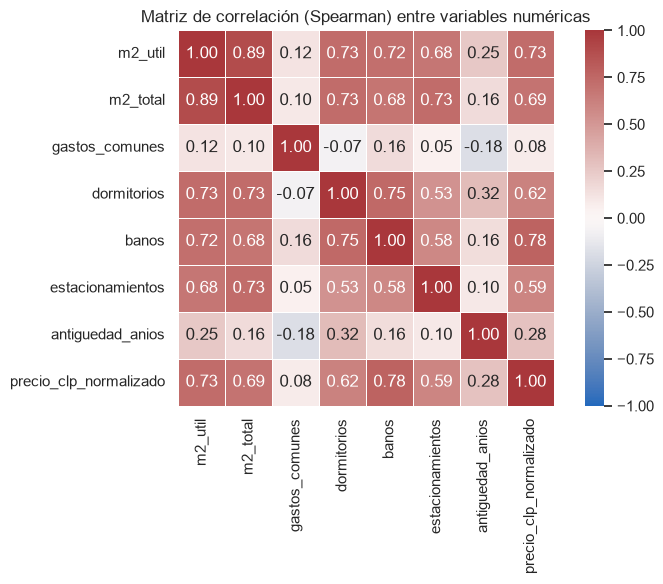

In [14]:
cols_corr = numericas + ['precio_clp_normalizado']
corr = con_precio[cols_corr].corr(method='spearman')
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5
)
plt.title('Matriz de correlación (Spearman) entre variables numéricas')
plt.tight_layout(); plt.show()

## Precio vs. m² útil

Scatter precio ~ m² útil, coloreado por tipo de propiedad, para ver la forma de la relación.

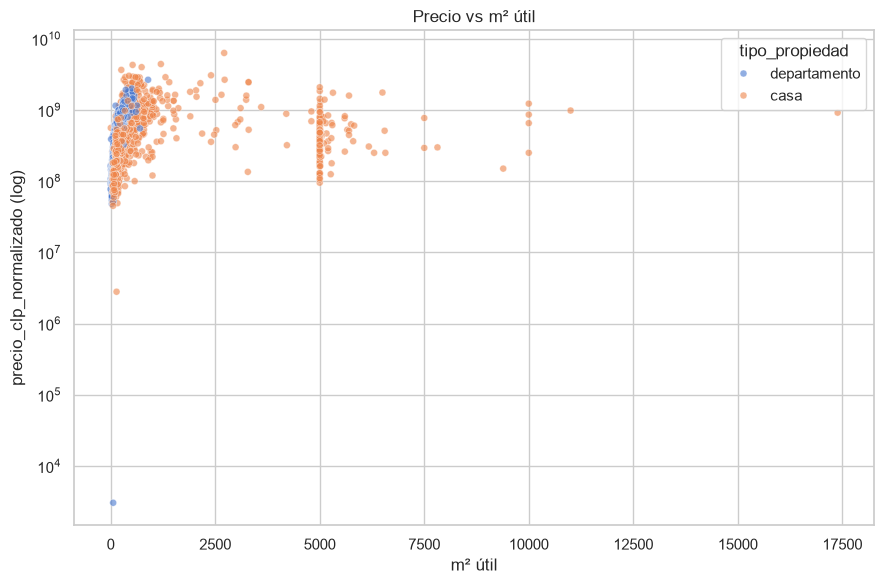

In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=relevante, x='m2_util', y='precio_clp_normalizado',
    hue='tipo_propiedad', alpha=0.6, s=25
)
plt.yscale('log')
plt.xlabel('m² útil'); plt.ylabel('precio_clp_normalizado (log)')
plt.title('Precio vs m² útil')
plt.tight_layout(); plt.show()

## Variables categóricas

Distribución por fuente, tipo de propiedad y comuna, y precio medio por comuna (las comunas con más avisos).

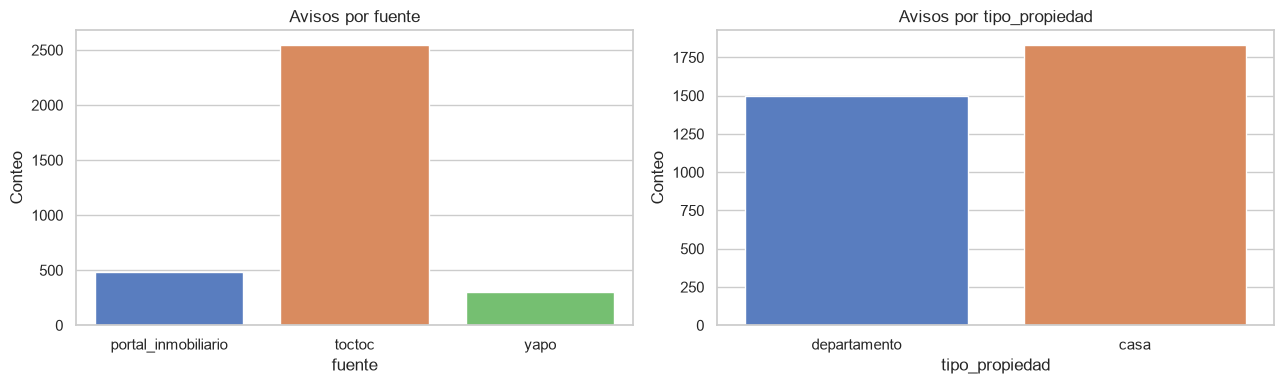

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x='fuente', hue='fuente', legend=False, ax=ax[0], palette='muted')
ax[0].set_title('Avisos por fuente')
ax[0].set_xlabel('fuente'); ax[0].set_ylabel('Conteo')
sns.countplot(data=df, x='tipo_propiedad', hue='tipo_propiedad', legend=False, ax=ax[1], palette='muted')
ax[1].set_title('Avisos por tipo_propiedad')
ax[1].set_xlabel('tipo_propiedad'); ax[1].set_ylabel('Conteo')
plt.tight_layout(); plt.show()

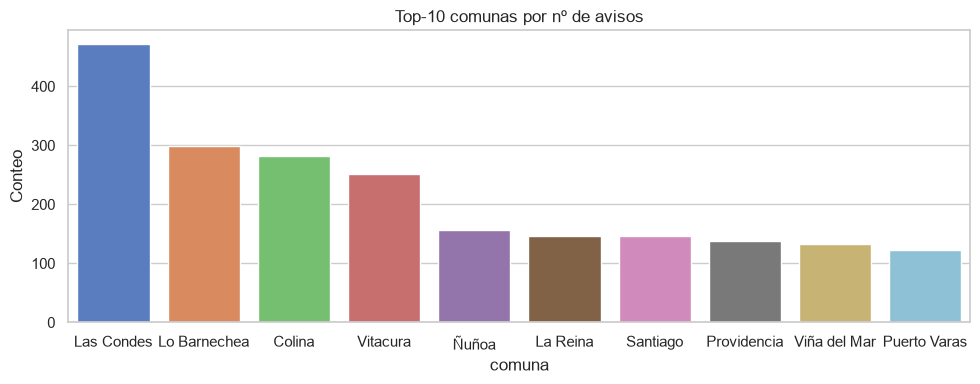

In [17]:
top_comunas = df['comuna'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_comunas.index, y=top_comunas.values, hue=top_comunas.index, legend=False, palette='muted')
plt.title('Top-10 comunas por nº de avisos')
plt.xlabel('comuna'); plt.ylabel('Conteo')
plt.tight_layout(); plt.show()

In [18]:
precio_por_comuna = (
    con_precio.groupby('comuna')['precio_clp_normalizado']
    .agg([('n', 'count'), ('mediana', 'median')])
    .sort_values('n', ascending=False)
    .head(10)
)
precio_por_comuna

,n,mediana
comuna,,
Las Condes,471,5.995781e+08
Lo Barnechea,298,1.010576e+09
Colina,282,6.498720e+08
Vitacura,251,7.339026e+08
Ñuñoa,156,2.202280e+08
Santiago,146,9.589950e+07
La Reina,146,5.838397e+08
Providencia,138,3.503934e+08
Viña del Mar,132,2.857093e+08


In [19]:
precio_por_fuente = (
    con_precio.groupby('fuente')['precio_clp_normalizado']
    .agg([('n', 'count'), ('mediana', 'median')])
)
precio_por_fuente

,n,mediana
fuente,,
portal_inmobiliario,480,5.718056e+08
toctoc,2550,4.161259e+08
yapo,300,1.908743e+08


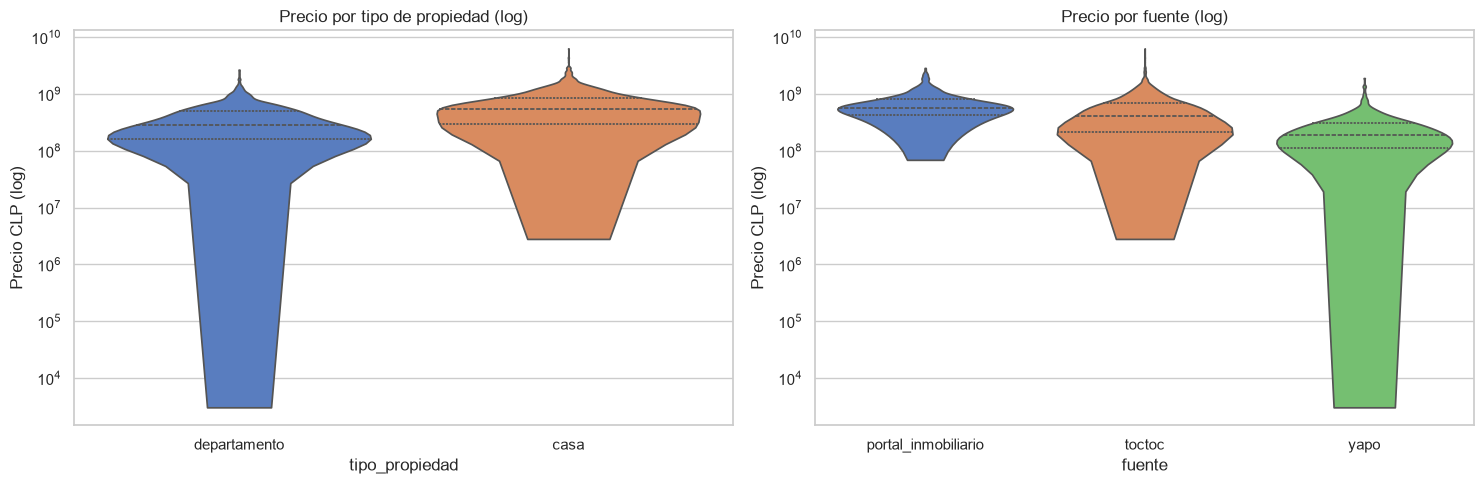

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.violinplot(
    data=con_precio, x='tipo_propiedad', y='precio_clp_normalizado',
    ax=axes[0], hue='tipo_propiedad', legend=False, inner='quart', cut=0
)
axes[0].set_yscale('log')
axes[0].set_title('Precio por tipo de propiedad (log)')
axes[0].set_xlabel('tipo_propiedad'); axes[0].set_ylabel('Precio CLP (log)')
sns.violinplot(
    data=con_precio, x='fuente', y='precio_clp_normalizado',
    ax=axes[1], hue='fuente', legend=False, inner='quart', cut=0
)
axes[1].set_yscale('log')
axes[1].set_title('Precio por fuente (log)')
axes[1].set_xlabel('fuente'); axes[1].set_ylabel('Precio CLP (log)')
plt.tight_layout(); plt.show()

In [21]:
fig = px.scatter(
    relevante,
    x='m2_util', y='precio_clp_normalizado',
    color='tipo_propiedad',
    size='precio_clp_normalizado',
    hover_data=['comuna', 'fuente', 'dormitorios', 'banos'],
    log_y=True, opacity=0.6, title='Precio vs m² útil (interactivo)'
)
fig.update_layout(template='plotly_white', legend_title='tipo_propiedad')
fig.show()

In [22]:
fig = px.box(
    con_precio[con_precio['comuna'].isin(top_comunas.index)],
    x='comuna', y='precio_clp_normalizado', color='tipo_propiedad',
    log_y=True, title='Precio por comuna (top 10, interactivo)'
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='comuna', yaxis_title='Precio CLP (log)'
)
fig.show()

In [23]:
fig = px.histogram(
    con_precio, x='precio_clp_normalizado', color='tipo_propiedad',
    log_x=True, marginal='box', nbins=60,
    title='Distribución de precio por tipo de propiedad (interactivo)'
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='Precio CLP (log)', yaxis_title='Conteo'
)
fig.show()

## Hallazgos e implicaciones para el modelado

Resumen de lo observado y recomendaciones de cara a la ingeniería de variables (`src/features/`) y al modelo.

### Distribución del precio
- Media CLP 531M vs mediana CLP 423M, con max CLP 6.31B → **cola larga a la derecha**. Modelar en escala logarítmica (`log1p(precio)`).

### Calidad de datos
- Casi inutilizables por nulos: `gastos_comunes` (97.7%), `antiguedad_anios` (97%), `bodega` (96.4%), `descripcion` (94%), `region` (94%), `estacionamientos` (90%).
- Moderados: `fecha_publicacion` (20.4%), `m2_util` (11%).
- Sólidas: precios, `comuna`, `m2_total` (<2%), `banos` (0.6%), `dormitorios` (0.4%).

### Correlación con el precio (Spearman)
- Fuerte: `banos` (0.780), `m2_util` (0.732), `m2_total` (0.692), `dormitorios` (0.616).
- Débil/poco fiable por bajo n: `estacionamientos` (0.595, n=332) y `antiguedad_anios` (0.284, n=100).

### Geografía
- Top comunas: Las Condes (471), Lo Barnechea (298), Colina (282), Vitacura (251).
- Mediana de precio muy dispar: Lo Barnechea CLP 1.01B vs Santiago CLP 96M → la **comuna explica gran parte de la variación** (feature geográfico clave, ponderar/estratificar).

### Fuente
- toctoc domina (2550), luego portal_inmobiliario (480) y yapo (300).
- Medianas distintas por fuente: yapo CLP 191M, toctoc CLP 416M, PI CLP 572M → **posible sesgo de fuente/segmento**; considerar `fuente` como feature o corregir por segmento.

### Precio por m²
- `precio_por_m2_util` mediana ~CLP 2.68M/m²; útil vs total muestra el valor del dato útil. `precio_por_m2_*` debería ser feature en `src/features/`.

### Recomendaciones
- Modelar `log1p(precio_clp_normalizado)`.
- Imputar nulos de `m2_total`/`m2_util` por comuna/tipo_propiedad.
- Validación estratificada por comuna y fuente para evitar sesgo.
